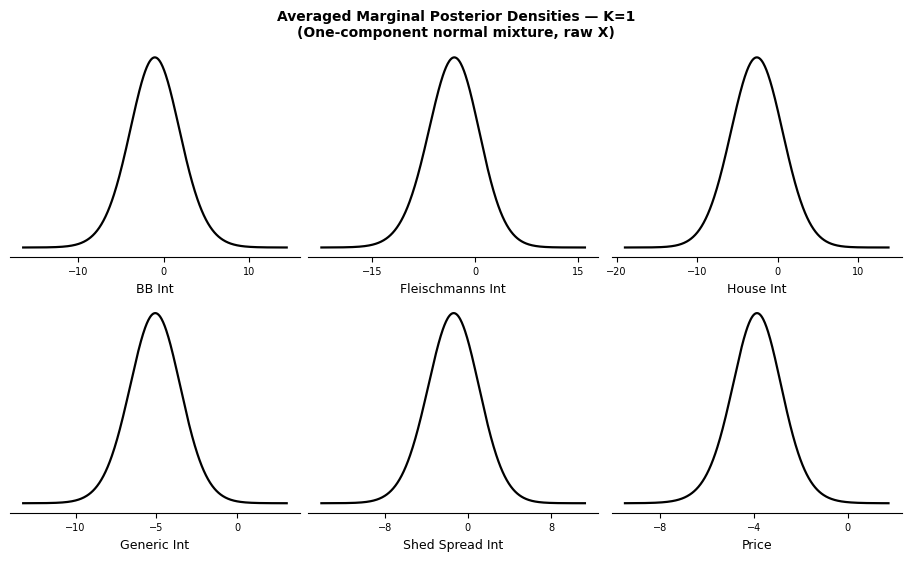

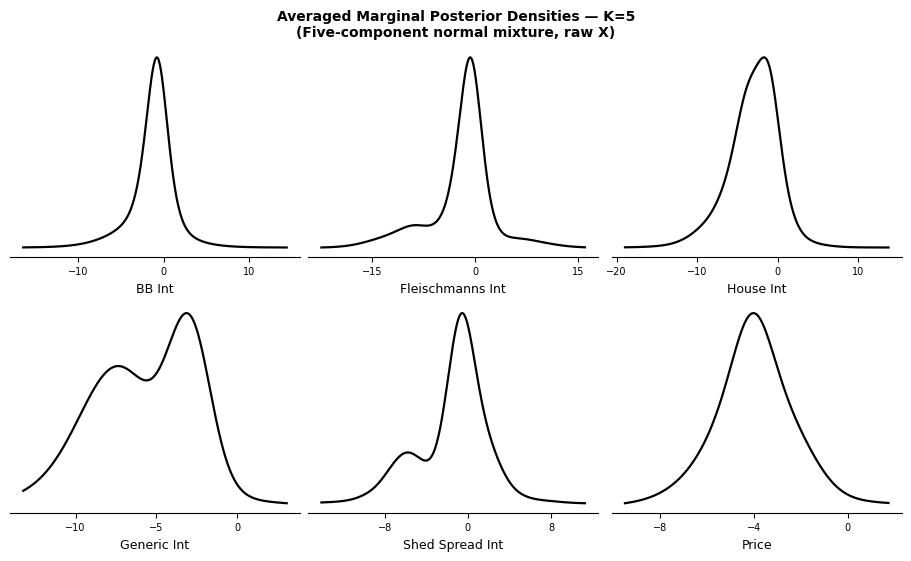

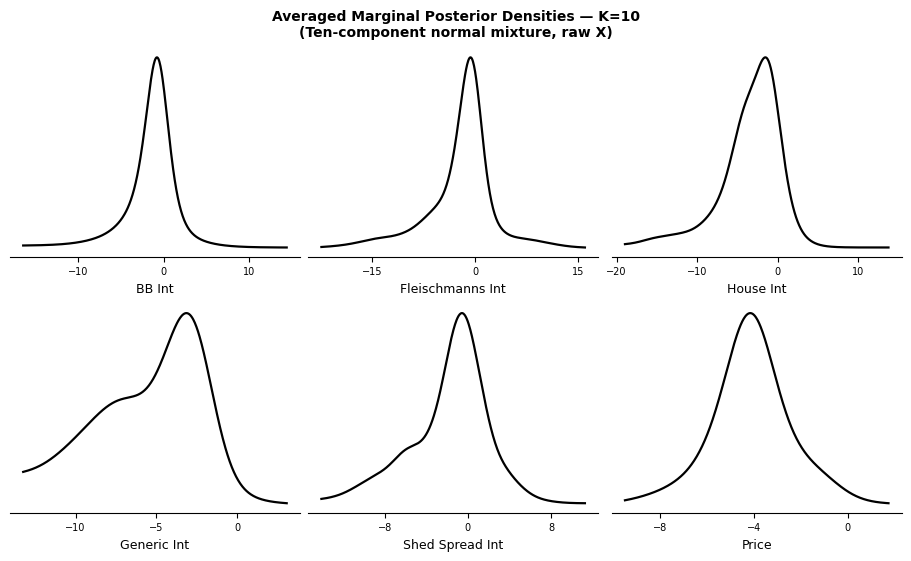

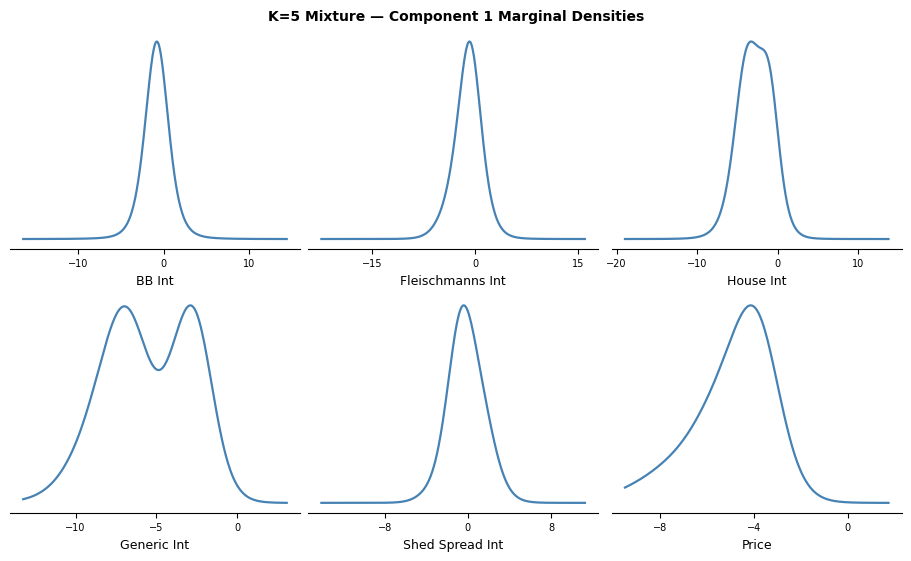

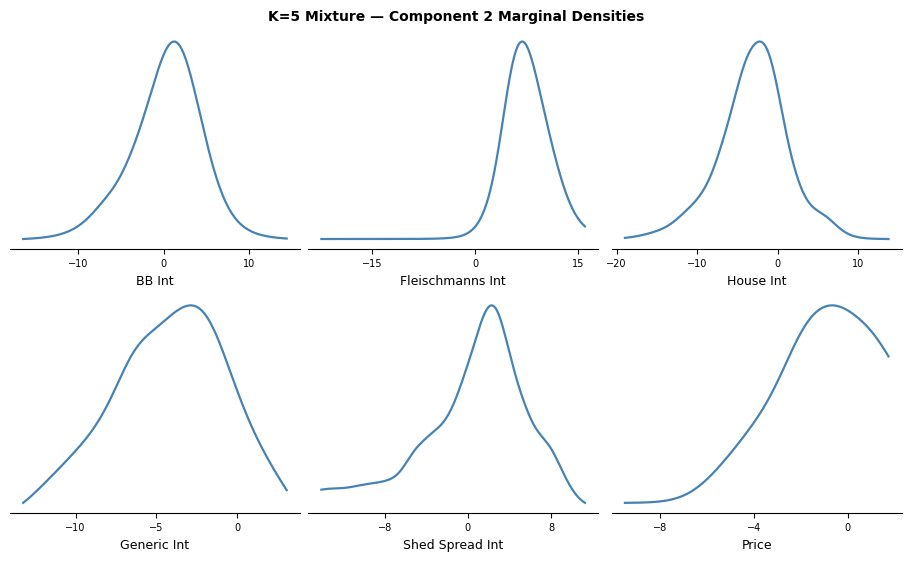

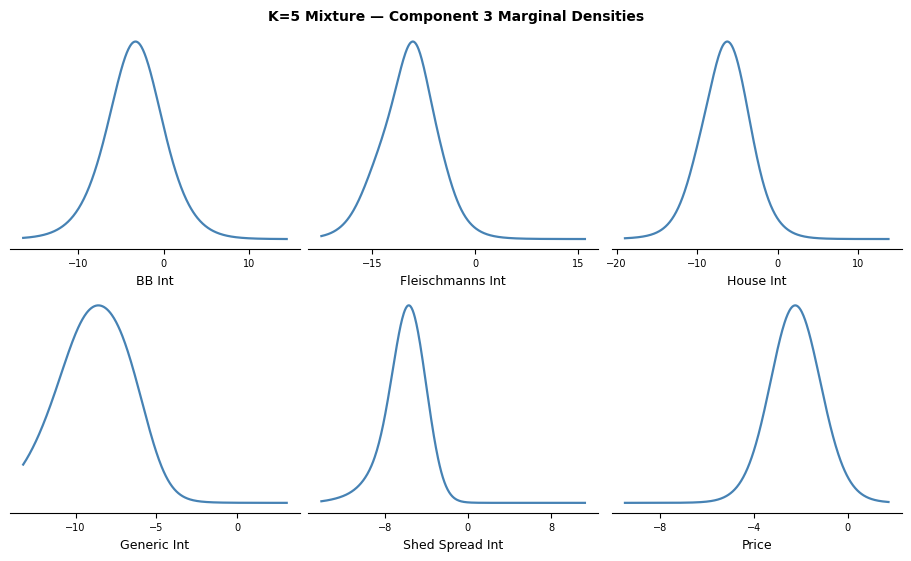

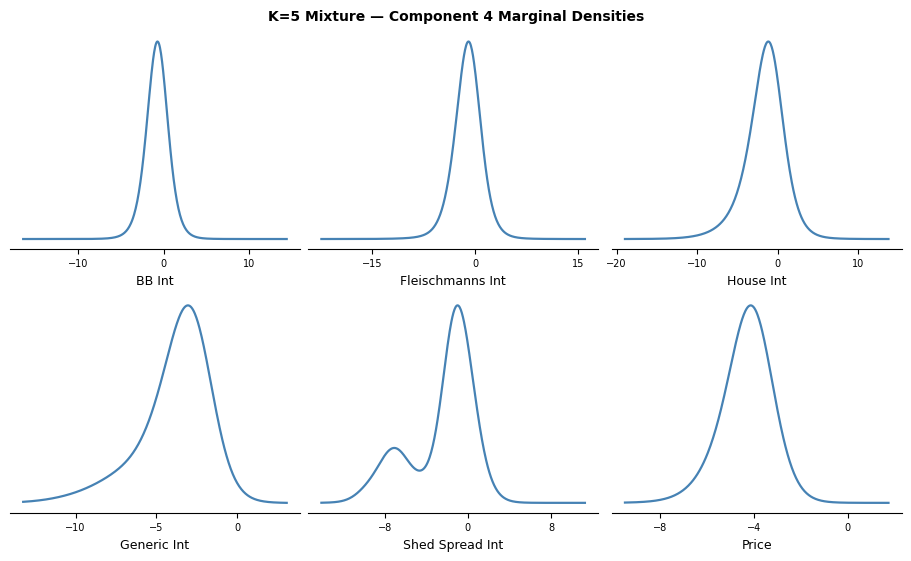

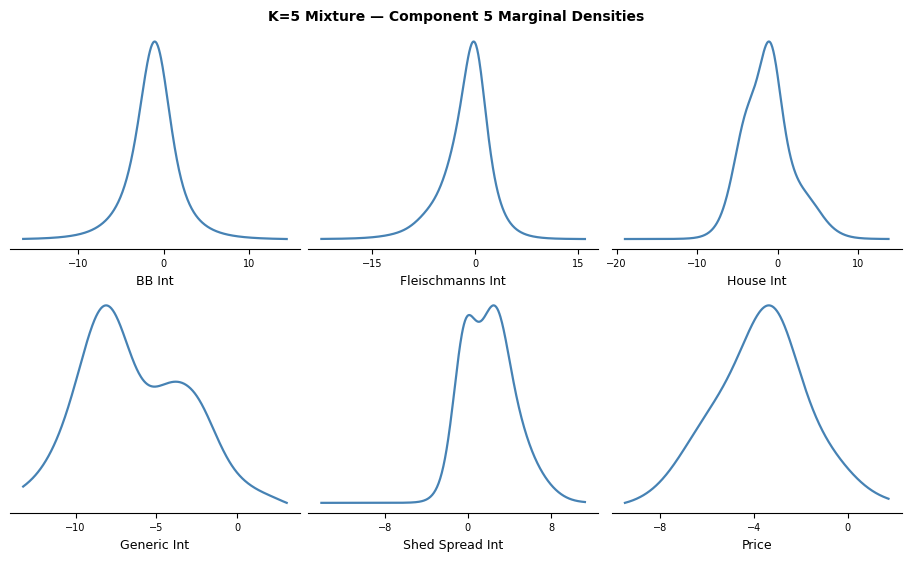

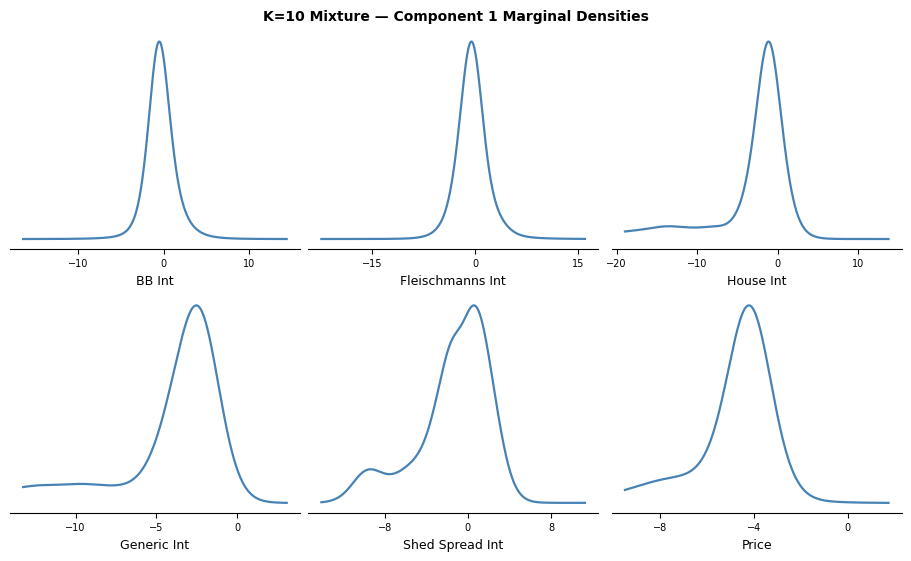

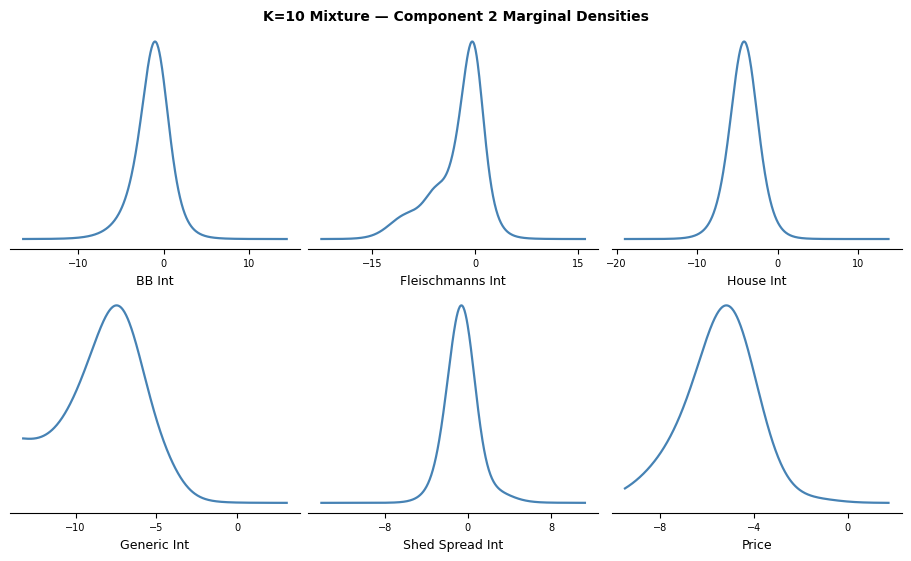

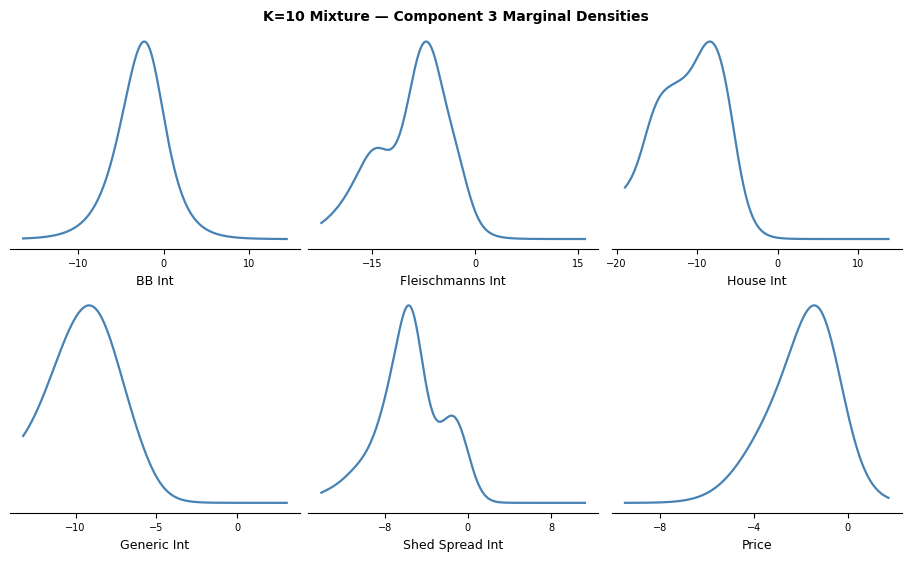

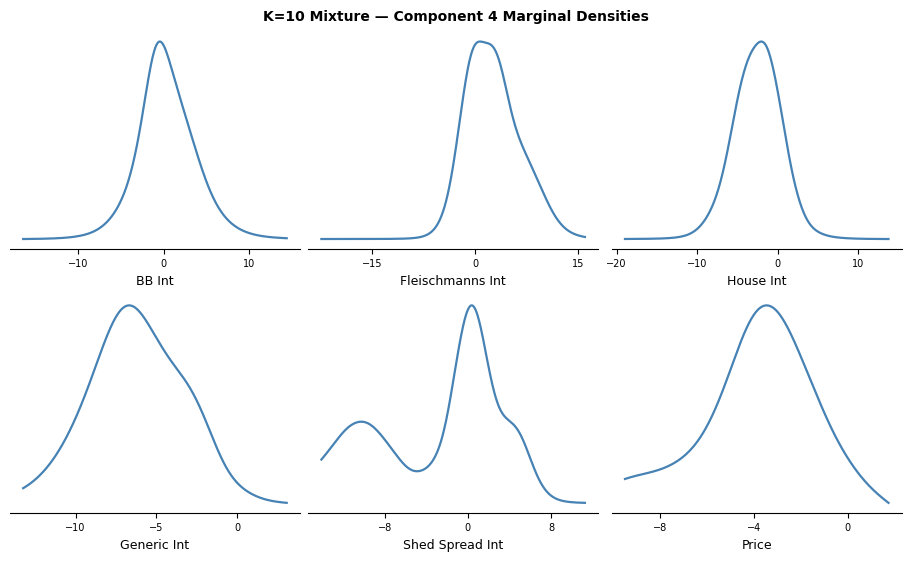

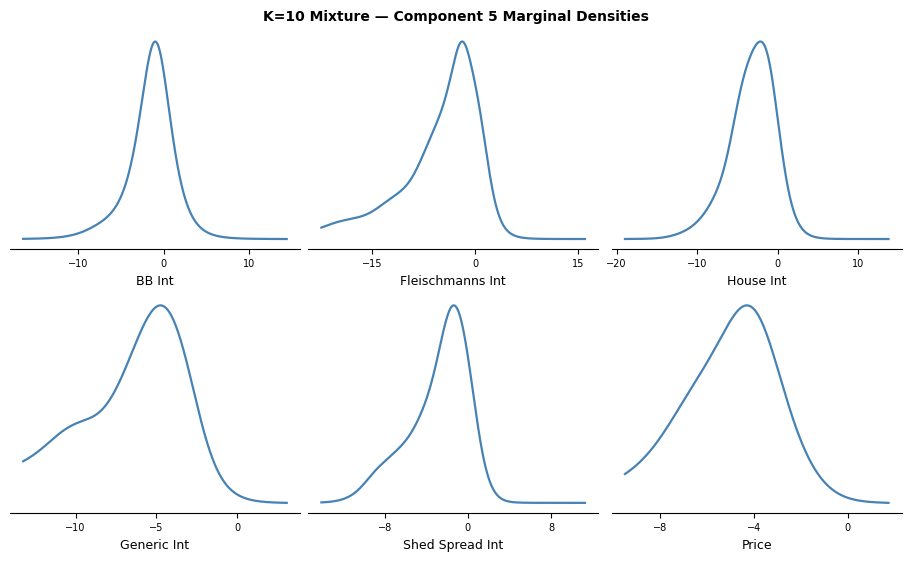

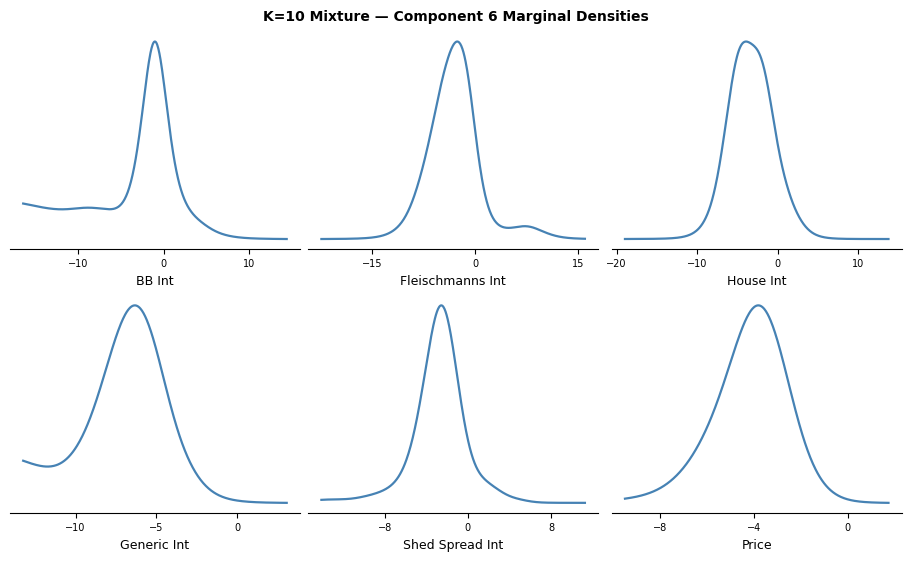

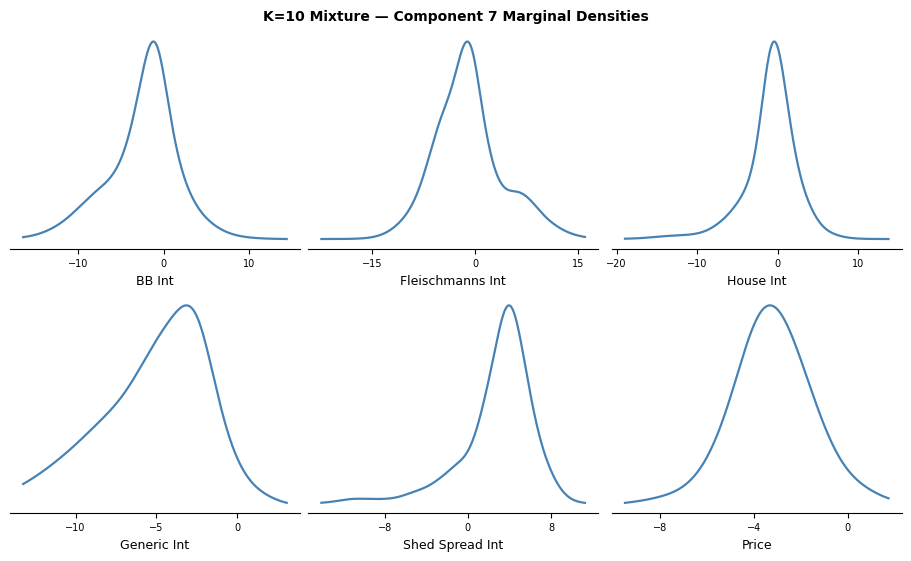

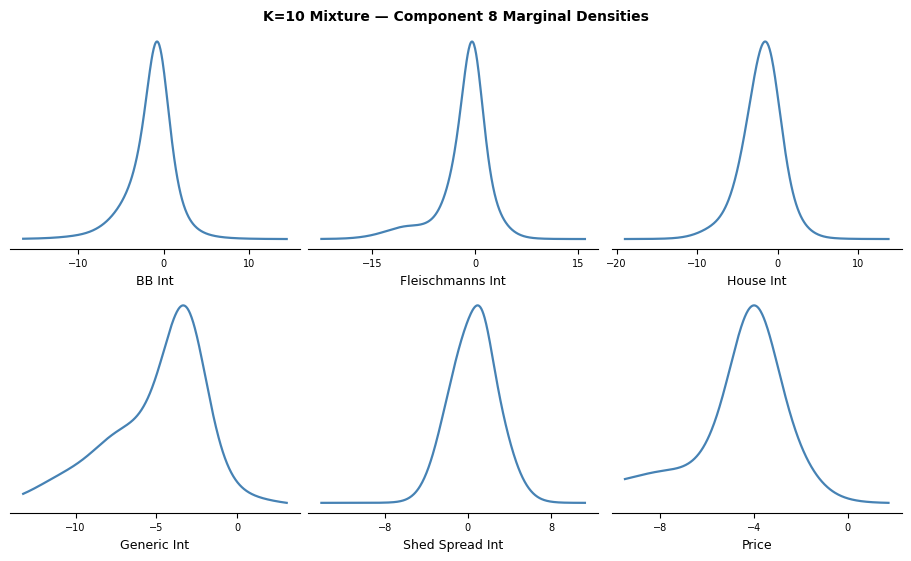

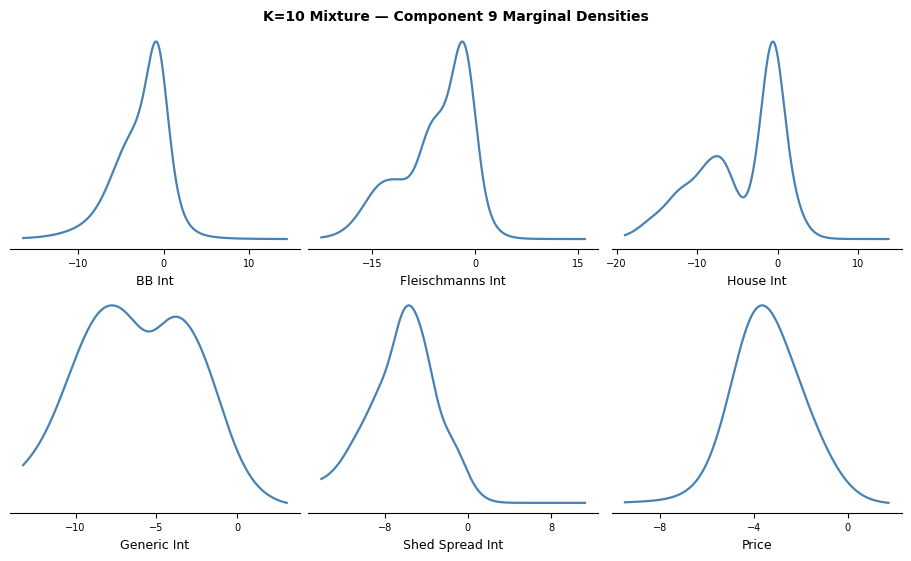

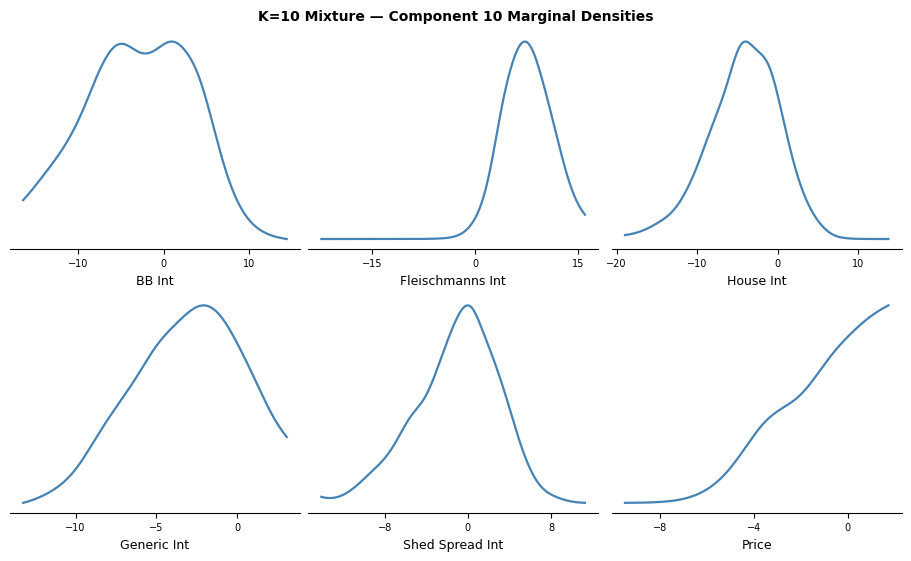

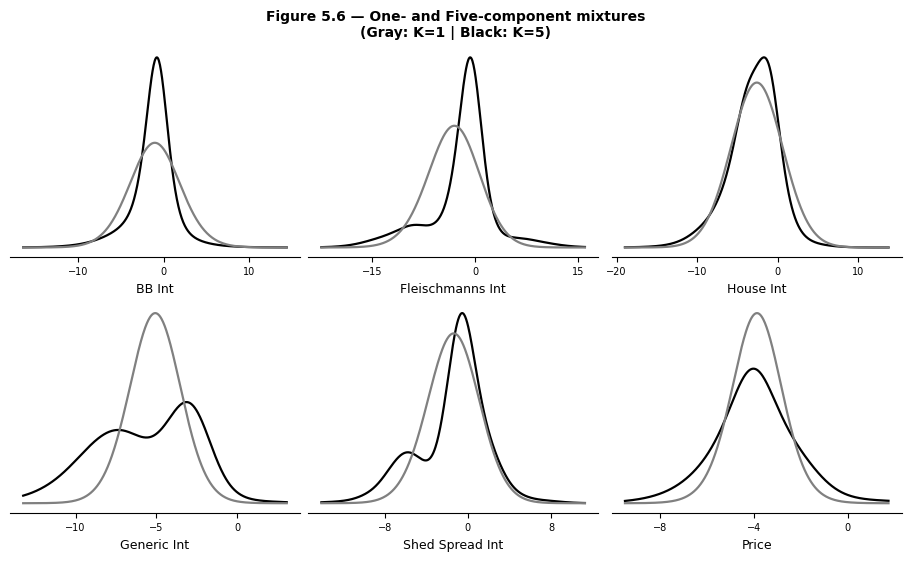

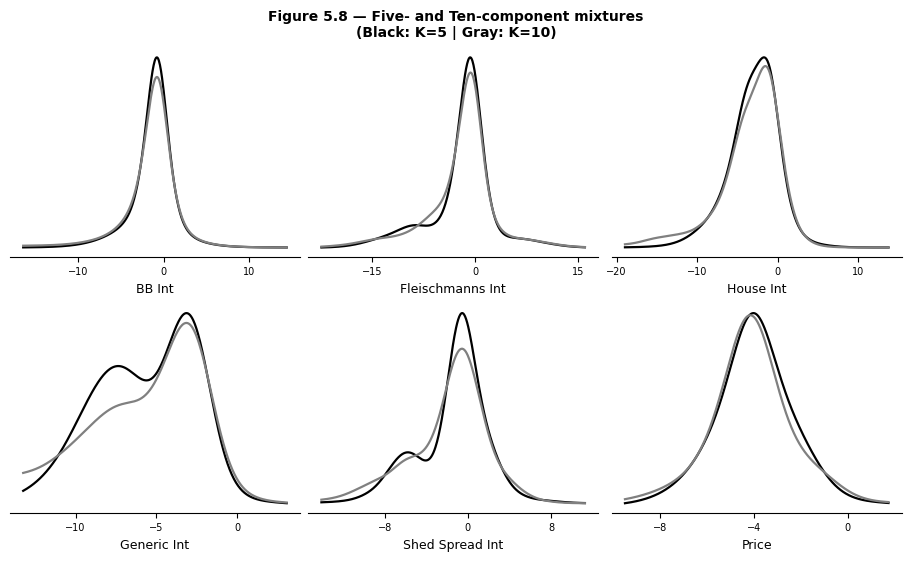

In [2]:
import pathlib
import numpy as np
import pyreadr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import norm

# ── Shared constants ───────────────────────────────────────────────────────────
N_GRID = 500
nvar   = 6
data_dir = pathlib.Path('Data')

plot_labels = [
    'BB Int', 'Fleischmanns Int', 'House Int',
    'Generic Int', 'Shed Spread Int', 'Price'
]

# ══════════════════════════════════════════════════════════════════════════════
# 1. DATA LOADING
# ══════════════════════════════════════════════════════════════════════════════

def load_draws(filepath, K):
    """
    Load RData and return:
      mu   : (R, K, nvar)  — component means
      std  : (R, K, nvar)  — marginal SDs from diagonal of each Σ_k
      pvec : (R, K)        — mixture weights
    """
    rdata   = pyreadr.read_r(str(filepath))
    mu_raw  = rdata['mu_draws_df'].values.astype(float)   # (R, K*nvar)
    cov_raw = rdata['cov_draws_df'].values.astype(float)  # (R, K*nvar²)
    R       = mu_raw.shape[0]

    if 'pvec_draws_df' in rdata:
        pvec = rdata['pvec_draws_df'].values.astype(float)  # (R, K)
    else:
        pvec = np.ones((R, K))  # K=1: weight is always 1

    mu   = mu_raw.reshape(R, K, nvar)
    std  = np.zeros((R, K, nvar))
    diag_idx = [j * nvar + j for j in range(nvar)]

    for k in range(K):
        cov_k         = cov_raw[:, k * nvar**2 : (k + 1) * nvar**2]
        std[:, k, :]  = np.sqrt(cov_k[:, diag_idx])

    return mu, std, pvec


mu1,  std1,  pvec1  = load_draws(data_dir / 'bayesm_output_margarine_1comp_rawX_noZ.RData',  K=1)
mu5,  std5,  pvec5  = load_draws(data_dir / 'bayesm_output_margarine_5comp_rawX_noZ.RData',  K=5)
mu10, std10, pvec10 = load_draws(data_dir / 'bayesm_output_margarine_10comp_rawX_noZ.RData', K=10)

# ══════════════════════════════════════════════════════════════════════════════
# 2. GRID CONSTRUCTION
#    Grids are anchored to K=1 (the smoothest reference) and widened
#    enough to capture the tails of K=5 and K=10 components.
# ══════════════════════════════════════════════════════════════════════════════

grids = []
for j in range(nvar):
    spread = np.sqrt(std1[:, 0, j].mean()**2 + mu1[:, 0, j].var())
    centre = mu1[:, 0, j].mean()
    grids.append(np.linspace(centre - 5 * spread, centre + 5 * spread, N_GRID))

# ══════════════════════════════════════════════════════════════════════════════
# 3. DENSITY EVALUATORS
# ══════════════════════════════════════════════════════════════════════════════

def marginal_density(mu, std, pvec, grids):
    """
    Evaluate eq. (5.5.19) for any K:
      d̄_j(x) = (1/R) Σ_r Σ_k pvec_r[k] · N(x ; μ_r[k,j], σ_r[k,j])
    Returns list of (N_GRID,) arrays, one per parameter j.
    """
    R, K, _ = mu.shape
    densities = []
    for j in range(nvar):
        x         = grids[j]
        density_j = np.zeros(N_GRID)
        for k in range(K):
            pdf_k      = norm.pdf(x[:, None], loc=mu[:, k, j], scale=std[:, k, j])
            density_j += np.mean(pvec[:, k] * pdf_k, axis=1)
        densities.append(density_j)
    return densities


def component_density(mu, std, k, grids):
    """
    Evaluate the un-weighted marginal density for a single component k:
      d̄_j(x) = (1/R) Σ_r N(x ; μ_r[k,j], σ_r[k,j])
    Returns list of (N_GRID,) arrays, one per parameter j.
    """
    densities = []
    for j in range(nvar):
        x          = grids[j]
        pdf_matrix = norm.pdf(x[:, None], loc=mu[:, k, j], scale=std[:, k, j])
        densities.append(pdf_matrix.mean(axis=1))
    return densities


# Overall mixture densities (used in comparison plots)
dens_K1  = marginal_density(mu1,  std1,  pvec1,  grids)
dens_K5  = marginal_density(mu5,  std5,  pvec5,  grids)
dens_K10 = marginal_density(mu10, std10, pvec10, grids)

# Per-component densities
dens_K5_comp  = [component_density(mu5,  std5,  k, grids) for k in range(5)]
dens_K10_comp = [component_density(mu10, std10, k, grids) for k in range(10)]

# ══════════════════════════════════════════════════════════════════════════════
# 4. PLOTTING HELPERS
# ══════════════════════════════════════════════════════════════════════════════

def _style_ax(ax, idx):
    """Apply shared axis styling."""
    ax.set_xlabel(plot_labels[idx], fontsize=9)
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='x', labelsize=7)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4, integer=False))


def plot_single(densities, title, color='black'):
    """2×3 grid showing the overall mixture density for one model."""
    fig, axes = plt.subplots(2, 3, figsize=(9, 5.5), constrained_layout=True)
    for idx, ax in enumerate(axes.flat):
        ax.plot(grids[idx], densities[idx], color=color, linewidth=1.6)
        _style_ax(ax, idx)
    fig.suptitle(title, fontsize=10, fontweight='bold')
    plt.show()


def plot_comparison(dens_A, dens_B, color_A, color_B, title):
    """2×3 grid overlaying two mixture densities."""
    fig, axes = plt.subplots(2, 3, figsize=(9, 5.5), constrained_layout=True)
    for idx, ax in enumerate(axes.flat):
        ax.plot(grids[idx], dens_A[idx], color=color_A, linewidth=1.6)
        ax.plot(grids[idx], dens_B[idx], color=color_B, linewidth=1.6)
        _style_ax(ax, idx)
    fig.suptitle(title, fontsize=10, fontweight='bold')
    plt.show()


def plot_component(dens_comp, comp_idx, K, color='steelblue'):
    """2×3 grid for a single mixture component's marginal densities."""
    fig, axes = plt.subplots(2, 3, figsize=(9, 5.5), constrained_layout=True)
    for idx, ax in enumerate(axes.flat):
        ax.plot(grids[idx], dens_comp[idx], color=color, linewidth=1.6)
        _style_ax(ax, idx)
    fig.suptitle(
        f'K={K} Mixture — Component {comp_idx + 1} Marginal Densities',
        fontsize=10, fontweight='bold'
    )
    plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 5. PRODUCE ALL PLOTS
# ══════════════════════════════════════════════════════════════════════════════

# ── 5a. K=1 overall density ───────────────────────────────────────────────────
plot_single(
    dens_K1,
    title='Averaged Marginal Posterior Densities — K=1\n(One-component normal mixture, raw X)'
)

# ── 5b. K=5 overall density ───────────────────────────────────────────────────
plot_single(
    dens_K5,
    title='Averaged Marginal Posterior Densities — K=5\n(Five-component normal mixture, raw X)'
)

# ── 5c. K=10 overall density ──────────────────────────────────────────────────
plot_single(
    dens_K10,
    title='Averaged Marginal Posterior Densities — K=10\n(Ten-component normal mixture, raw X)'
)

# ── 5d. Individual component plots for K=5 ────────────────────────────────────
for k in range(5):
    plot_component(dens_K5_comp[k], comp_idx=k, K=5)

# ── 5e. Individual component plots for K=10 ───────────────────────────────────
for k in range(10):
    plot_component(dens_K10_comp[k], comp_idx=k, K=10)

# ── 5f. Comparison: K=1 (gray) vs K=5 (black) — Figure 5.6 ───────────────────
plot_comparison(
    dens_A=dens_K5,  color_A='black',
    dens_B=dens_K1,  color_B='gray',
    title='Figure 5.6 — One- and Five-component mixtures\n(Gray: K=1 | Black: K=5)'
)

# ── 5g. Comparison: K=5 (black) vs K=10 (gray) — Figure 5.8 ──────────────────
plot_comparison(
    dens_A=dens_K5,  color_A='black',
    dens_B=dens_K10, color_B='gray',
    title='Figure 5.8 — Five- and Ten-component mixtures\n(Black: K=5 | Gray: K=10)'
)